In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Makes random results reproducible
random.seed(42)
np.random.seed(42)

In [2]:
# PART 1: DESIGN THE MAZE ENVIRONMENT


In [3]:
# Maze size
ROWS = 5
COLS = 5

# Starting and goal positions
START = (0, 0)
GOAL = (4, 4)

# Walls or blocked cells
WALLS = {
    (0, 3),
    (1, 1),
    (1, 3),
    (2, 1),
    (3, 3),
    (4, 1)
}
# Penalty states
PENALTY_STATES = {
    (2, 3),
    (3, 1)
}


In [4]:
# Actions
# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right

ACTIONS = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1)
}

ACTION_NAMES = {
    0: "Up",
    1: "Down",
    2: "Left",
    3: "Right"
}

# Symbols used to display the learned policy
ACTION_SYMBOLS = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}


In [5]:
# CONVERT GRID POSITION TO STATE NUMBER

"""
  Converts a maze location such as (2, 3)
    into a single state number.

    Example:
    (0, 0) -> 0
    (0, 1) -> 1
    (1, 0) -> 5
"""
def state_number(position):
  row, column = position
  return row * COLS + column


In [6]:
# ENVIRONMENT STEP FUNCTION
"""
    Takes an action from the current position.

    Returns:
        next_position
        reward
        done
    """
def take_action(position, action):
    row, column = position

    # Get movement for selected action
    row_change, column_change = ACTIONS[action]

    new_row = row + row_change
    new_column = column + column_change

    next_position = (new_row, new_column)

    # Check whether the move goes outside the maze whether it is valid or invalid
    outside_maze = (
        new_row < 0
        or new_row >= ROWS
        or new_column < 0
        or new_column >= COLS
    )

    # Check whether the new position is a wall
    hits_wall = next_position in WALLS

    if outside_maze or hits_wall:

        # Agent stays in the same position
        next_position = position

        # Negative reward for invalid move
        reward = -5
        done = False
        return next_position, reward, done

    # GOAL STATE

    if next_position == GOAL:
        reward = 100
        done = True
        return next_position, reward, done

    # PENALTY STATE

    if next_position in PENALTY_STATES:

        reward = -10
        done = False

        return next_position, reward, done

    # NORMAL MOVEMENT

    reward = -1
    done = False

    return next_position, reward, done


# EPSILON-GREEDY ACTION SELECTION

def choose_action(state, q_table, epsilon):

    random_number = random.random()
    if random_number < epsilon:
        return random.choice(list(ACTIONS.keys()))
    else:
        return np.argmax(q_table[state])


In [7]:
 #PART 2: Q-LEARNING TRAINING FUNCTION
EPISODES = 1000
ALPHA = 0.1
GAMMA = 0.9
EPSILON = 1.0
EPSILON_DECAY = 0.995
MINIMUM_EPSILON = 0.05
MAX_STEPS = 100

def train_q_learning(
    episodes=1000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_decay=0.995,
    minimum_epsilon=0.05,
    max_steps=100
):


    """
    Trains the agent using the Q-learning algorithm.

    Hyperparameters:

    alpha   = learning rate
    gamma   = discount factor
    epsilon = exploration rate
    """

    # Total number of states
    number_of_states = ROWS * COLS

    number_of_actions = len(ACTIONS)

    # Initialize all Q-values to zero
    q_table = np.zeros(
        (number_of_states, number_of_actions)
    )

    # Lists used to track learning progress
    episode_rewards = []
    episode_steps = []
    q_changes = []

    # TRAINING LOOP

    for episode in range(episodes):

        # Start every episode at START
        current_position = START

        current_state = state_number(current_position)

        total_reward = 0

        total_q_change = 0

        steps = 0

        # ONE EPISODE

        for step in range(max_steps):

            # Select action using epsilon-greedy strategy
            action = choose_action(
                current_state,
                q_table,
                epsilon
            )

            # Agent performs the action
            next_position, reward, done = take_action(
                current_position,
                action
            )

            next_state = state_number(next_position)

            # Q-LEARNING UPDATE

            old_q_value = q_table[
                current_state,
                action
            ]

            # Best future Q-value
            if done:

                best_future_q = 0

            else:

                best_future_q = np.max(
                    q_table[next_state]
                )

            # Q-learning formula:
            #
            # Q(s,a) = Q(s,a) + alpha *[reward +gamma * max Q(s',a')- Q(s,a)]

            new_q_value = (
                old_q_value
                + alpha
                * (
                    reward
                    + gamma * best_future_q
                    - old_q_value
                )
            )

            # Update Q-table
            q_table[
                current_state,
                action
            ] = new_q_value

            # Track how much Q-value changed
            total_q_change += abs(
                new_q_value - old_q_value
            )

            # Add reward
            total_reward += reward

            # Move agent to next state
            current_position = next_position

            current_state = next_state

            steps += 1

            # Stop episode if goal is reached
            if done:
                break

        # Save episode information
        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        q_changes.append(total_q_change)

        # EPSILON DECAY

        epsilon = max(
            minimum_epsilon,
            epsilon * epsilon_decay
        )

    return (
        q_table,
        episode_rewards,
        episode_steps,
        q_changes
    )




In [8]:
# DISPLAY MAZE
# ============================================================

def display_maze():

    print("\nMAZE ENVIRONMENT\n")

    for row in range(ROWS):

        for column in range(COLS):

            position = (row, column)

            if position == START:
                print(" S ", end=" ")

            elif position == GOAL:
                print(" G ", end=" ")

            elif position in WALLS:
                print(" X ", end=" ")

            elif position in PENALTY_STATES:
                print(" P ", end=" ")

            else:
                print(" . ", end=" ")

        print()

    print("\nS = Start")
    print("G = Goal")
    print("X = Wall")
    print("P = Penalty")
    print(". = Open Cell")

display_maze()


MAZE ENVIRONMENT

 S   .   .   X   .  
 .   X   .   X   .  
 .   X   .   P   .  
 .   P   .   X   .  
 .   X   .   .   G  

S = Start
G = Goal
X = Wall
P = Penalty
. = Open Cell


In [9]:
# DISPLAY LEARNED POLICY
# ============================================================

def display_policy(q_table):

    print("\nLEARNED POLICY\n")

    for row in range(ROWS):

        for column in range(COLS):

            position = (row, column)

            if position == START:

                state = state_number(position)

                best_action = np.argmax(
                    q_table[state]
                )

                print(
                    "S" + ACTION_SYMBOLS[best_action],
                    end="   "
                )

            elif position == GOAL:

                print("G ", end="   ")

            elif position in WALLS:

                print("X ", end="   ")

            else:

                state = state_number(position)

                best_action = np.argmax(
                    q_table[state]
                )

                print(
                    ACTION_SYMBOLS[best_action],
                    end="    "
                )

        print()
q_table, rewards, steps, q_changes = train_q_learning(
    episodes=EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    minimum_epsilon=MINIMUM_EPSILON,
    max_steps=MAX_STEPS
)
display_policy(q_table)


LEARNED POLICY

S→   →    ↓    X    ↓    
↑    X    ↓    X    ↓    
↑    X    ↓    →    ↓    
→    →    ↓    X    ↓    
↑    X    →    →    G    


In [10]:
# TEST THE TRAINED AGENT
# ============================================================

def test_agent(q_table, max_steps=100):

    position = START

    path = [position]

    total_reward = 0

    for step in range(max_steps):

        state = state_number(position)

        # Choose best learned action
        action = np.argmax(
            q_table[state]
        )

        next_position, reward, done = take_action(
            position,
            action
        )

        total_reward += reward

        path.append(next_position)

        position = next_position

        if done:
            break

    return path, total_reward
best_path, final_reward = test_agent(
    q_table
)

print("\nBEST PATH FOUND BY TRAINED AGENT")

for position in best_path:

    print(position, end=" -> ")

print("Goal")

print(
    "\nNumber of steps:",
    len(best_path) - 1
)

print(
    "Total reward:",
    final_reward
)



BEST PATH FOUND BY TRAINED AGENT
(0, 0) -> (0, 1) -> (0, 2) -> (1, 2) -> (2, 2) -> (3, 2) -> (4, 2) -> (4, 3) -> (4, 4) -> Goal

Number of steps: 8
Total reward: 93


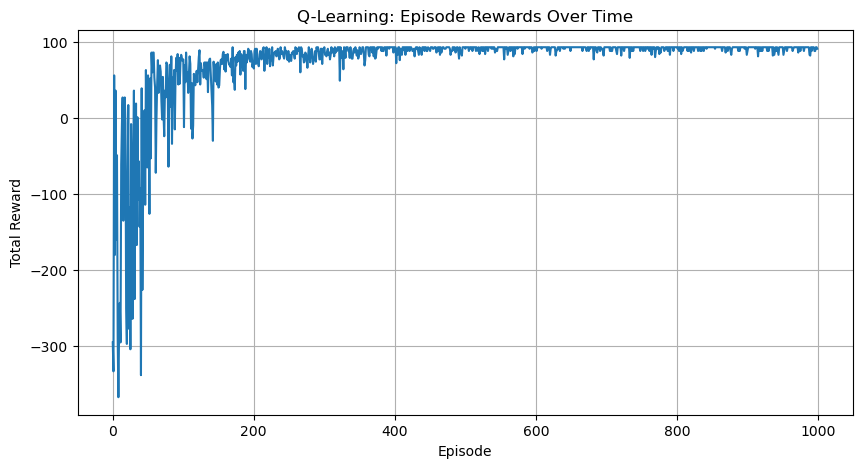

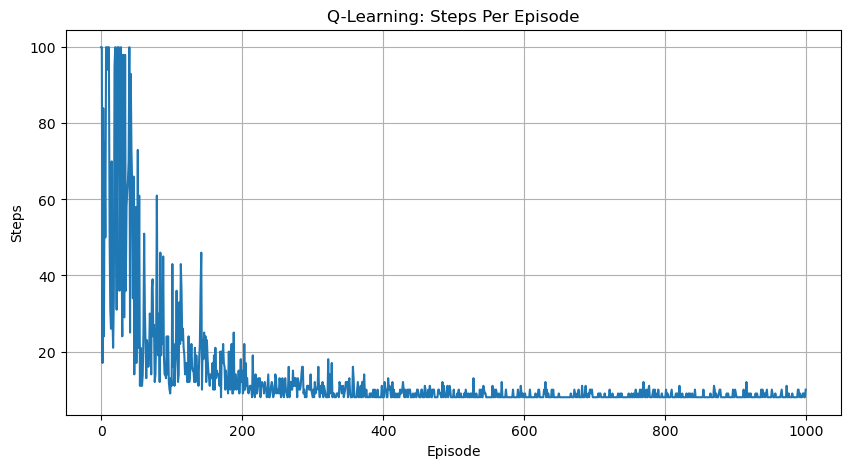

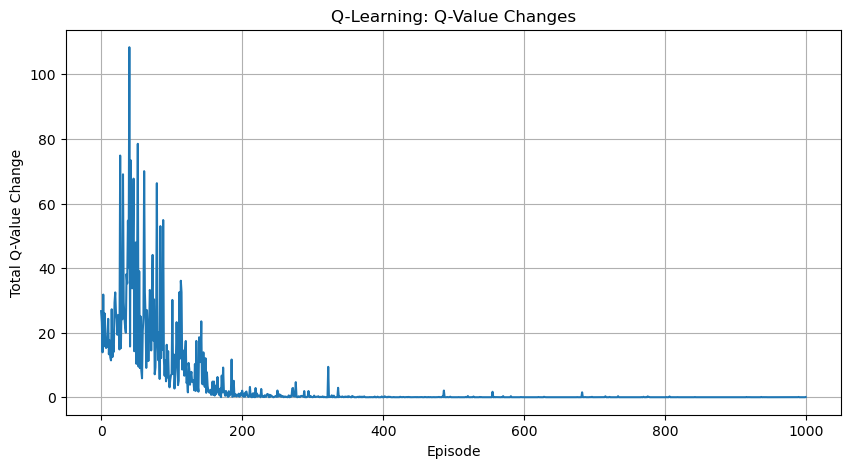

In [11]:
# PART 3: PLOT

def plot_learning_progress(
    rewards,
    steps,
    q_changes
):


    plt.figure(figsize=(10, 5))

    plt.plot(rewards)

    plt.xlabel("Episode")

    plt.ylabel("Total Reward")

    plt.title(
        "Q-Learning: Episode Rewards Over Time"
    )

    plt.grid()

    plt.show()

    plt.figure(figsize=(10, 5))

    plt.plot(steps)

    plt.xlabel("Episode")

    plt.ylabel("Steps")

    plt.title(
        "Q-Learning: Steps Per Episode"
    )

    plt.grid()

    plt.show()

    plt.figure(figsize=(10, 5))

    plt.plot(q_changes)

    plt.xlabel("Episode")

    plt.ylabel("Total Q-Value Change")

    plt.title(
        "Q-Learning: Q-Value Changes"
    )

    plt.grid()

    plt.show()
plot_learning_progress(rewards,steps,q_changes)




HYPERPARAMETER COMPARISON
-------------------------------------------------------------------------------------
Experiment     Alpha     Gamma     Epsilon     Avg Reward     Avg Steps      
-------------------------------------------------------------------------------------
Experiment 1   0.1       0.9       1.0         91.66          8.46           
Experiment 2   0.5       0.9       1.0         91.73          8.32           
Experiment 3   0.1       0.5       1.0         91.58          8.44           
Experiment 4   0.1       0.9       0.3         91.89          8.33           


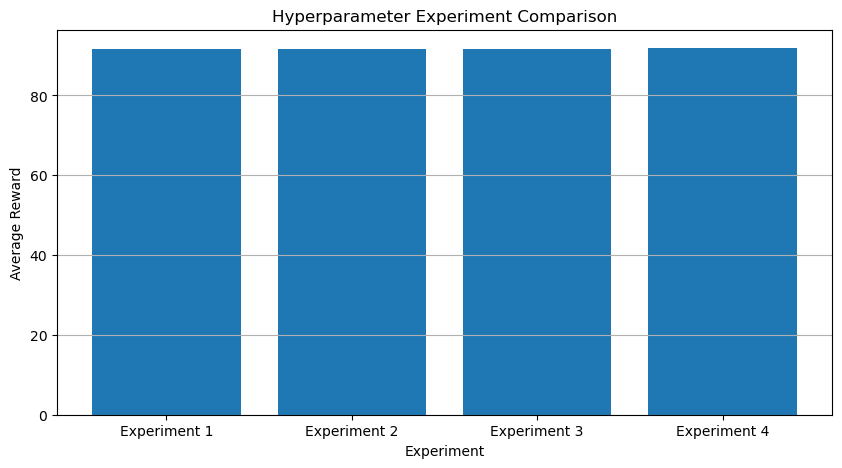

In [12]:
# PART 4: HYPERPARAMETER

def hyperparameter_experiments():

    experiments = [

        {
            "name": "Experiment 1",
            "alpha": 0.1,
            "gamma": 0.9,
            "epsilon": 1.0
        },

        {
            "name": "Experiment 2",
            "alpha": 0.5,
            "gamma": 0.9,
            "epsilon": 1.0
        },

        {
            "name": "Experiment 3",
            "alpha": 0.1,
            "gamma": 0.5,
            "epsilon": 1.0
        },

        {
            "name": "Experiment 4",
            "alpha": 0.1,
            "gamma": 0.9,
            "epsilon": 0.3
        }
    ]

    results = []

    for experiment in experiments:

        (
            q_table,
            rewards,
            steps,
            q_changes
        ) = train_q_learning(

            episodes=1000,

            alpha=experiment["alpha"],

            gamma=experiment["gamma"],

            epsilon=experiment["epsilon"]
        )

        # Average reward from final 100 episodes
        average_reward = np.mean(
            rewards[-100:]
        )

        # Average steps from final 100 episodes
        average_steps = np.mean(
            steps[-100:]
        )

        results.append({

            "name": experiment["name"],

            "alpha": experiment["alpha"],

            "gamma": experiment["gamma"],

            "epsilon": experiment["epsilon"],

            "average_reward": average_reward,

            "average_steps": average_steps
        })

    print("\nHYPERPARAMETER COMPARISON")
    print("-" * 85)

    print(
        f"{'Experiment':<15}"
        f"{'Alpha':<10}"
        f"{'Gamma':<10}"
        f"{'Epsilon':<12}"
        f"{'Avg Reward':<15}"
        f"{'Avg Steps':<15}"
    )

    print("-" * 85)

    for result in results:

        print(
            f"{result['name']:<15}"
            f"{result['alpha']:<10}"
            f"{result['gamma']:<10}"
            f"{result['epsilon']:<12}"
            f"{result['average_reward']:<15.2f}"
            f"{result['average_steps']:<15.2f}"
        )

    # COMPARISON GRAPH

    experiment_names = [
        result["name"]
        for result in results
    ]

    average_rewards = [
        result["average_reward"]
        for result in results
    ]

    plt.figure(figsize=(10, 5))

    plt.bar(
        experiment_names,
        average_rewards
    )

    plt.xlabel("Experiment")

    plt.ylabel("Average Reward")

    plt.title(
        "Hyperparameter Experiment Comparison"
    )

    plt.grid(axis="y")

    plt.show()
hyperparameter_experiments()

In [13]:
# TRAINING SUMMARY
# ============================================================

print("TRAINING SUMMARY")
print("-" * 20)

print("Training episodes:",EPISODES)

print("Learning rate (alpha):",ALPHA)

print("Discount factor (gamma):",GAMMA)

print("Initial epsilon:",EPSILON)

print("Epsilon decay:",EPSILON_DECAY)

print("Minimum epsilon:",MINIMUM_EPSILON)

print("Average reward during last 100 episodes:",round(np.mean(rewards[-100:]),2))

print("Average number of steps during last 100 episodes:",round(np.mean(steps[-100:]),2))


TRAINING SUMMARY
--------------------
Training episodes: 1000
Learning rate (alpha): 0.1
Discount factor (gamma): 0.9
Initial epsilon: 1.0
Epsilon decay: 0.995
Minimum epsilon: 0.05
Average reward during last 100 episodes: 91.28
Average number of steps during last 100 episodes: 8.42
